In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sea

In [3]:
df = pd.read_csv(r"C:\Users\windows 10\Downloads\archive (3)\Reviews.csv")

In [4]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df.shape

(568454, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [7]:
df.isna().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

# Data Cleaning:-

In [8]:
df = df[['Score' , 'Text']]

In [9]:
df.isna().sum()

Score    0
Text     0
dtype: int64

In [10]:
df.head(2)

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...


In [11]:
print('The comment of first person and ')
print('Rating of the person:- ', df['Score'].iloc[0])
df['Text'].iloc[0]

The comment of first person and 
Rating of the person:-  5


'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

In [12]:
df['Text'].iloc[1]

'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".'

# Rating Destribution:-

In [13]:
Score_dis = df['Score'].value_counts().sort_index()

In [14]:
Score_dis

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

In [15]:
print('PERCENTAGES\n')
for score , count in Score_dis.items():
    per = (count/len(df)) * 100
    print(f'{score} stars :- { per:.2f}%')

PERCENTAGES

1 stars :- 9.19%
2 stars :- 5.24%
3 stars :- 7.50%
4 stars :- 14.19%
5 stars :- 63.88%


In [16]:
for score in [1,2,3,4,5]:
    simple_rev = df[df['Score'] == score]['Text'].iloc[0]
    print(f'\n⭐  {score}-review')
    print(f'{simple_rev}\n')
    


⭐  1-review
Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".


⭐  2-review
If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.


⭐  3-review
This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.


⭐  4-review
This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy tre

# Data Visualisation:-

In [17]:
df['text_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

In [18]:
df.head()

,Score,Text,text_length,word_count
0,5,I have bought several of the Vitality canned d...,263,48
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31
2,4,This is a confection that has been around a fe...,509,94
3,2,If you are looking for the secret ingredient i...,219,41
4,5,Great taffy at a great price. There was a wid...,140,27


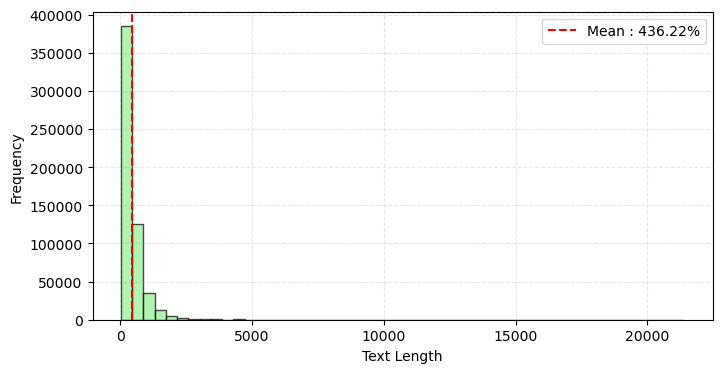

In [19]:
plt.figure(figsize = (8,4))
plt.hist(df['text_length'] , bins = 50, alpha = 0.7 , color = 'lightgreen', edgecolor = 'black')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.axvline(df['text_length'].mean(),color = 'red', linestyle = '--',
           label= f'Mean : {df['text_length'].mean():.2f}%')
plt.grid(alpha = 0.3, linestyle = '--')
plt.legend()

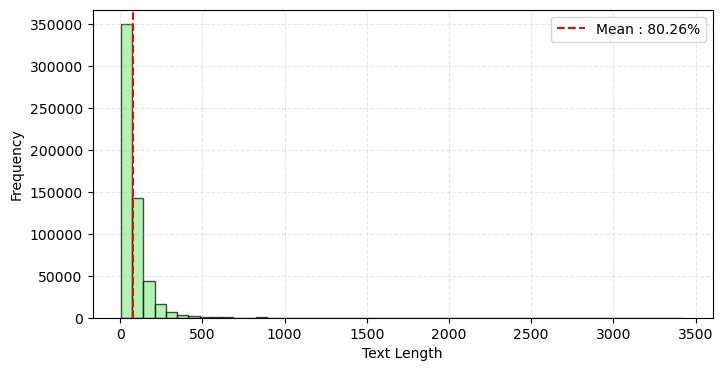

In [20]:
plt.figure(figsize = (8,4))
plt.hist(df['word_count'] , bins = 50, alpha = 0.7 , color = 'lightgreen', edgecolor = 'black')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.axvline(df['word_count'].mean(),color = 'red', linestyle = '--',
           label= f'Mean : {df['word_count'].mean():.2f}%')
plt.grid(alpha = 0.3, linestyle = '--')
plt.legend()

In [21]:
df.head(3)

,Score,Text,text_length,word_count
0,5,I have bought several of the Vitality canned d...,263,48
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31
2,4,This is a confection that has been around a fe...,509,94


We will take only 1&2 ratings as bad and 4&5 ratings as good, the 3 is the most confusing one.

In [22]:
df_binary = df[df['Score'] != 3].copy()
df_binary['sentiment'] = (df_binary['Score'] >= 4).astype(int)

In [23]:
df_binary.head(2)

,Score,Text,text_length,word_count,sentiment
0,5,I have bought several of the Vitality canned d...,263,48,1
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31,0


In [24]:
df_binary['Score'].value_counts()

Score
5    363122
4     80655
1     52268
2     29769
Name: count, dtype: int64

The Three Star Revius Are Removed.

In [25]:
print(f"The Negative revies (1 - 2) :- {sum(df_binary['sentiment'] == 0):,}")

The Negative revies (1 - 2) :- 82,037


In [26]:
print(f"The Positive revies (4 - 5) :- {sum(df_binary['sentiment'] == 1):,}")

The Positive revies (4 - 5) :- 443,777


In [27]:
print(df_binary[df_binary['sentiment'] == 0].value_counts())

Score  Text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [28]:
df_binary['sentiment'].value_counts()

sentiment
1    443777
0     82037
Name: count, dtype: int64

In [29]:
df_binary['sentiment'].value_counts().iloc[1]

np.int64(82037)

The class imbalence:-

In [30]:
neg_rev = (sum(df_binary['sentiment'] == 0) / len(df_binary)) * 100
pos_rev = (sum(df_binary['sentiment'] == 1) / len(df_binary)) * 100
print('Positive Reviews:- ', pos_rev)
print('Negative Reviews:- ' , neg_rev)

Positive Reviews:-  84.3980951439102
Negative Reviews:-  15.601904856089796


# Handle Class Imbalence:-

In [31]:
from sklearn.utils import resample

In [32]:
negative_reviews = df_binary[df_binary['sentiment'] == 0]
positive_reviews = df_binary[df_binary['sentiment'] == 1]

In [33]:
n_minority = len(negative_reviews)
positive_downsampled = resample(positive_reviews , replace = False , n_samples = n_minority)

In [34]:
positive_downsampled

,Score,Text,text_length,word_count,sentiment
556273,5,I've tried several brands of black tea and I l...,281,54,1
60312,4,This is very powdery milk. When I pour it out...,107,22,1
342864,5,"The beans arrived as pictured, in a shrink wra...",225,39,1
508470,5,Pooch Passions please change back to old/origi...,444,81,1
24066,5,Absolutely very tasty chips. The best I have e...,129,24,1
...,...,...,...,...,...
259323,5,The dried cherries are wonderful. I did crunc...,264,50,1
231959,5,My grandkids love this gummy fruit snack - I l...,113,23,1
261603,5,This oatmeal has excellent texture and tastes ...,212,40,1
564244,5,I have ordered this particular tea a couple of...,234,48,1


In [35]:
df_balenced = pd.concat([negative_reviews ,positive_downsampled])

In [36]:
df_balenced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164074 entries, 1 to 559657
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Score        164074 non-null  int64 
 1   Text         164074 non-null  object
 2   text_length  164074 non-null  int64 
 3   word_count   164074 non-null  int64 
 4   sentiment    164074 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 7.5+ MB


In [37]:
df_balenced.head(10)

,Score,Text,text_length,word_count,sentiment
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31,0
3,2,If you are looking for the secret ingredient i...,219,41,0
12,1,My cats have been happily eating Felidae Plati...,399,79,0
16,2,I love eating them and they are good for watch...,195,42,0
26,1,"The candy is just red , No flavor . Just plan...",88,20,0
50,1,"This oatmeal is not good. Its mushy, soft, I d...",89,19,0
62,1,Arrived in 6 days and were so stale i could no...,71,17,0
67,2,"I purchased the Mango flavor, and to me it doe...",479,87,0
73,1,Buyer Beware Please! This sweetener is not for...,1746,306,0
74,2,It is okay. I would not go out of my way to b...,57,15,0


We Need To Shuffle the data and adjust the index values:-

In [38]:
df_balenced = df_balenced.sample(frac = 1).reset_index(drop = True)

In [39]:
df_balenced.head()

,Score,Text,text_length,word_count,sentiment
0,4,I pretty much shop exclusively in the natural/...,1590,306,1
1,5,"Seriously. We were against the sugary, artific...",413,73,1
2,1,I live in Wisconsin and love cheese of all kin...,504,100,0
3,1,This what they call licorice has no taste at a...,231,44,0
4,4,"Fortunately, my kittens have had no ill behavi...",705,131,1


In [40]:
neg_rev = (sum(df_balenced['sentiment'] == 0) / len(df_balenced)) * 100
pos_rev = (sum(df_balenced['sentiment'] == 1) / len(df_balenced)) * 100
print('Positive Reviews:- ', pos_rev)
print('Negative Reviews:- ' , neg_rev)

Positive Reviews:-  50.0
Negative Reviews:-  50.0


As The Data Set Size is heavy. If we perform An RNN The Traing Time will be high so Reducing the Data Points to Even more small.

In [41]:
sample_size = 25000
df_sample = df_balenced.sample(n = sample_size)

In [42]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 5613 to 81374
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Score        25000 non-null  int64 
 1   Text         25000 non-null  object
 2   text_length  25000 non-null  int64 
 3   word_count   25000 non-null  int64 
 4   sentiment    25000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 1.1+ MB


In [43]:
neg_rev = (sum(df_sample['sentiment'] == 0) / len(df_sample)) * 100
pos_rev = (sum(df_sample['sentiment'] == 1) / len(df_sample)) * 100
print('Positive Reviews:- ', pos_rev)
print('Negative Reviews:- ' , neg_rev)

Positive Reviews:-  50.296
Negative Reviews:-  49.704


They Are Mostly Equal No Class Imbalence Exists

In [44]:
df_sample.sample(3)

,Score,Text,text_length,word_count,sentiment
105463,5,My picky one year old cat loves this.She will ...,442,88,1
70552,5,"This tea not only aids in digestion, but this...",236,42,1
8077,2,This rootbeer extract is unlike any I've ever ...,271,49,0


In [45]:
df_sample['Text'].iloc[0]

"I'm always looking for a single-use coffee that is strong enough for my taste without using two pods ... this isn't it. In fact, I've had cheap instant coffee that taste better.<br /><br />I use my pod  for a quick cup or take them with me when I'm traveling, so I don't expect the product to taste like my fresh ground brewed coffee. But I do expect flavor. The flavor of this coffee was similar to re-used grounds.<br /><br />The only redeeming quality about this  Marley product is that it is a free-trade, organic product.<br /><br />I'm not sure what I'm going to do with the left-over packages because I don't want to insult guests by serving it. It seems a waste to just throw it away.  Maybe I can use it in the garden."

In [46]:
df_sample['Text'].iloc[10]

'Found this weak and like the phony cappuccinos you buy at 7-11.  None my favorite that is for sure.<br />I ended up giving it away'

In [47]:
df_sample['Text'].iloc[3]

"Goya's Tembleque (Puerto Rican Style Coconut Pudding)is absolutely DELICIOUS! It's light and RICH at the same time! The pure white colour is delightful and the texture is supreme! I adore it sprinkled with powered cinnamon and can eat it any time! The flavour is packed! I always have this in the house!"

In [48]:
df_sample['Text'].iloc[555]

'My dog absolutely loves these bones. I prefer the large size as to the extra large. They keep my dog busy and do not make a mess on the carpet.'

# Text Preprocessing:-

  * Remove All The Special Characters.
  * Convert All The Words To Lower Case.
  * Remove The Extra White Spaces.
    

In [49]:
import re
def Clean_Text(text):
    Text = text.lower()
    Text = re.sub(r'<[^>]+>',' ',Text)
    Text = re.sub(r'[^a-zA-Z0-9\s]' , '' , Text)
    Text = ' '.join(Text.split())
    return Text

In [50]:
df_sample.head()

,Score,Text,text_length,word_count,sentiment
5613,1,I'm always looking for a single-use coffee tha...,727,135,0
284,1,"I am very dissatisfied with this product, the ...",200,35,0
135562,5,Buy this product with the upfront understandin...,499,100,1
86931,5,Goya's Tembleque (Puerto Rican Style Coconut P...,303,52,1
4785,5,I've been a faithful follower of a massive muf...,828,150,1


In [51]:
df_sample['Cleaned_Text'] = df_sample['Text'].apply(Clean_Text)

In [52]:
df_sample.head()

,Score,Text,text_length,word_count,sentiment,Cleaned_Text
5613,1,I'm always looking for a single-use coffee tha...,727,135,0,im always looking for a singleuse coffee that ...
284,1,"I am very dissatisfied with this product, the ...",200,35,0,i am very dissatisfied with this product the r...
135562,5,Buy this product with the upfront understandin...,499,100,1,buy this product with the upfront understandin...
86931,5,Goya's Tembleque (Puerto Rican Style Coconut P...,303,52,1,goyas tembleque puerto rican style coconut pud...
4785,5,I've been a faithful follower of a massive muf...,828,150,1,ive been a faithful follower of a massive muff...


So WE Can see a new colom called cleaned_text, 

In [53]:
df_sample['Text'].iloc[10]

'Found this weak and like the phony cappuccinos you buy at 7-11.  None my favorite that is for sure.<br />I ended up giving it away'

In [54]:
df_sample['Cleaned_Text'].iloc[10]

'found this weak and like the phony cappuccinos you buy at 711 none my favorite that is for sure i ended up giving it away'

# Deep Learning Librabries:-

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf

In [56]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN , LSTM , Dense , Bidirectional , Dropout
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
import pickle


# Tokenization:-

In [57]:
MAX_FEATURES = 10000
MAX_LEN = 100

X = df_sample['Cleaned_Text'].values
Y = df_sample['sentiment'].values

tokenizer = Tokenizer(num_words = MAX_FEATURES , oov_token = '<OOV>')
tokenizer.fit_on_texts(X)

In [94]:
with open('amezon_sentiment_tokenizer.pkl','wb') as f:
    pickle.dump(tokenizer,f)

In [58]:
X_sequences = tokenizer.texts_to_sequences(X)

In [59]:

df_sample['Cleaned_Text'].iloc[0]

'im always looking for a singleuse coffee that is strong enough for my taste without using two pods this isnt it in fact ive had cheap instant coffee that taste better i use my pod for a quick cup or take them with me when im traveling so i dont expect the product to taste like my fresh ground brewed coffee but i do expect flavor the flavor of this coffee was similar to reused grounds the only redeeming quality about this marley product is that it is a freetrade organic product im not sure what im going to do with the leftover packages because i dont want to insult guests by serving it it seems a waste to just throw it away maybe i can use it in the garden'

In [60]:
print(X_sequences[0] , end = ',')

[86, 184, 230, 12, 5, 1, 42, 13, 10, 239, 220, 12, 14, 31, 205, 201, 121, 574, 9, 331, 7, 11, 372, 104, 43, 528, 642, 42, 13, 31, 96, 3, 90, 14, 1195, 12, 5, 625, 128, 37, 260, 29, 18, 48, 47, 86, 2771, 26, 3, 64, 677, 2, 32, 6, 31, 24, 14, 256, 602, 848, 42, 17, 3, 79, 677, 46, 2, 46, 8, 9, 42, 16, 630, 6, 8897, 1147, 2, 67, 5956, 173, 61, 9, 2384, 32, 10, 13, 7, 10, 5, 1, 172, 32, 86, 15, 185, 70, 86, 215, 6, 79, 18, 2, 3331, 627, 69, 3, 64, 157, 6, 4712, 1662, 88, 511, 7, 7, 361, 5, 414, 6, 34, 634, 7, 222, 289, 3, 50, 90, 7, 11, 2, 1489],

# Paddding:-

In [61]:
X_padded = pad_sequences(X_sequences , maxlen = MAX_LEN , padding = 'post' , truncating = 'post')

In [62]:
print(X_padded[0])

[  86  184  230   12    5    1   42   13   10  239  220   12   14   31
  205  201  121  574    9  331    7   11  372  104   43  528  642   42
   13   31   96    3   90   14 1195   12    5  625  128   37  260   29
   18   48   47   86 2771   26    3   64  677    2   32    6   31   24
   14  256  602  848   42   17    3   79  677   46    2   46    8    9
   42   16  630    6 8897 1147    2   67 5956  173   61    9 2384   32
   10   13    7   10    5    1  172   32   86   15  185   70   86  215
    6   79]


In [63]:
x_train , x_test , y_train , y_test = train_test_split(X_padded , Y , test_size = 0.20 , stratify = Y)

# Recurrent Neural Network:- RNN

In [64]:
def create_rnn():
    model = Sequential([
        Embedding(input_dim = MAX_FEATURES , output_dim = 128 , input_length = MAX_LEN),
        SimpleRNN(units = 64, return_sequences = False),
        Dropout(0.4),
        Dense(32 , activation = 'relu'),
        Dense(1, activation = 'sigmoid')
    ])
    return model
        

In [65]:
RNN_Model = create_rnn()

C:\Users\windows 10\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [66]:
RNN_Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [67]:
RNN_Model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [68]:
RNN_history = RNN_Model.fit(
    x_train , y_train,
    batch_size = 128,
    epochs = 5,
    validation_split = 0.2
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.5166 - loss: 0.6934 - val_accuracy: 0.5385 - val_loss: 0.6882
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.5909 - loss: 0.6638 - val_accuracy: 0.5428 - val_loss: 0.6922
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.6463 - loss: 0.6028 - val_accuracy: 0.5475 - val_loss: 0.7314
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.7217 - loss: 0.4989 - val_accuracy: 0.5805 - val_loss: 0.7549
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.7959 - loss: 0.4027 - val_accuracy: 0.5630 - val_loss: 0.8523


In [69]:
final_train_acc = RNN_history.history['accuracy'][-1]
print(f'Final Trainig Accuracy :- {final_train_acc}')
final_val_acc = RNN_history.history['val_accuracy'][-1]
print(f'The Final Validation Accuracy :- {final_val_acc}')

Final Trainig Accuracy :- 0.7959374785423279
The Final Validation Accuracy :- 0.5630000233650208


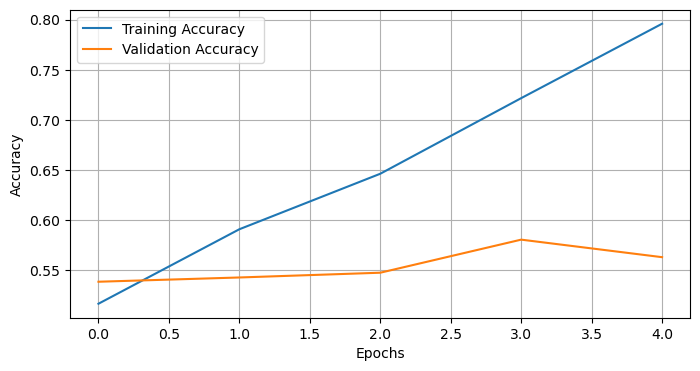

In [70]:
plt.figure(figsize = (8,4))
plt.plot(RNN_history.history['accuracy'] , label = 'Training Accuracy')
plt.plot(RNN_history.history['val_accuracy'] , label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

 # LSTM - MODEL:-

Epoch 1/5


C:\Users\windows 10\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 194ms/step - accuracy: 0.5184 - loss: 0.6907 - val_accuracy: 0.5770 - val_loss: 0.6775
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 220ms/step - accuracy: 0.5741 - loss: 0.6623 - val_accuracy: 0.5965 - val_loss: 0.6477
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 166ms/step - accuracy: 0.7346 - loss: 0.5606 - val_accuracy: 0.7872 - val_loss: 0.5061
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 175ms/step - accuracy: 0.8273 - loss: 0.4524 - val_accuracy: 0.7715 - val_loss: 0.5651
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy: 0.8378 - loss: 0.4320 - val_accuracy: 0.8108 - val_loss: 0.4878
Final Trainig Accuracy :- 0.8378124833106995
The Final Validation Accuracy :- 0.8107500076293945


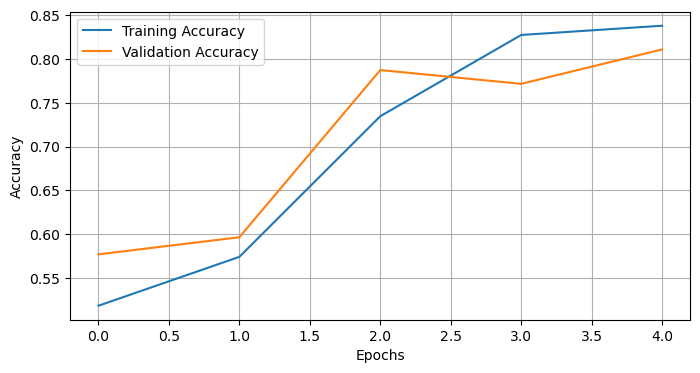

In [71]:
def create_lstm():
    model = Sequential([
        Embedding(input_dim = MAX_FEATURES , output_dim = 128 , input_length = MAX_LEN),
        LSTM(units = 64, return_sequences = False),
        Dropout(0.4),
        Dense(32 , activation = 'relu'),
        Dense(1, activation = 'sigmoid')
    ])
    return model
lstm_model = create_lstm()
lstm_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

lstm_history = lstm_model.fit(
    x_train , y_train,
    batch_size = 128,
    epochs = 5,
    validation_split = 0.2
)

final_train_acc = lstm_history.history['accuracy'][-1]
print(f'Final Trainig Accuracy :- {final_train_acc}')
final_val_acc = lstm_history.history['val_accuracy'][-1]
print(f'The Final Validation Accuracy :- {final_val_acc}')

plt.figure(figsize = (8,4))
plt.plot(lstm_history.history['accuracy'] , label = 'Training Accuracy')
plt.plot(lstm_history.history['val_accuracy'] , label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

# Lets Increase The Epcos and See:- which one is performing better.

In [72]:
# RNN increased epochs:-

In [73]:
RNN_history = RNN_Model.fit(
    x_train , y_train,
    batch_size = 128,
    epochs = 10,
    validation_split = 0.2
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.8580 - loss: 0.3178 - val_accuracy: 0.5395 - val_loss: 0.9639
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.8910 - loss: 0.2580 - val_accuracy: 0.5805 - val_loss: 1.0575
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.9356 - loss: 0.1666 - val_accuracy: 0.5817 - val_loss: 1.1225
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - accuracy: 0.9398 - loss: 0.1559 - val_accuracy: 0.5832 - val_loss: 1.2442
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.9694 - loss: 0.0871 - val_accuracy: 0.5753 - val_loss: 1.4372
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.9719 - loss: 0.0748 - val_accuracy: 0.5690 - val_loss: 1.6406
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.9835 - loss: 0.0505 - val_accuracy: 0.5735 - val_loss: 1.6622
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9831 - loss: 0.0436 - va

In [74]:
final_train_acc_ep_15 = RNN_history.history['accuracy'][-1]
print(f'Final Trainig Accuracy :- {final_train_acc_ep_15}')
final_val_acc_ep_15 = RNN_history.history['val_accuracy'][-1]
print(f'The Final Validation Accuracy :- {final_val_acc_ep_15}')

Final Trainig Accuracy :- 0.9888749718666077
The Final Validation Accuracy :- 0.5805000066757202


In [75]:
# LSTM increases epochs:-

In [76]:
lstm_history = lstm_model.fit(
    x_train , y_train,
    batch_size = 128,
    epochs = 10,
    validation_split = 0.2)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 179ms/step - accuracy: 0.8004 - loss: 0.4531 - val_accuracy: 0.5138 - val_loss: 0.7026
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 155ms/step - accuracy: 0.6135 - loss: 0.5882 - val_accuracy: 0.5723 - val_loss: 0.6496
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 180ms/step - accuracy: 0.8158 - loss: 0.4191 - val_accuracy: 0.8357 - val_loss: 0.4329
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 161ms/step - accuracy: 0.9038 - loss: 0.2663 - val_accuracy: 0.8482 - val_loss: 0.3879
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 177ms/step - accuracy: 0.9383 - loss: 0.1931 - val_accuracy: 0.8605 - val_loss: 0.3869
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 179ms/step - accuracy: 0.9589 - loss: 0.1350 - val_accuracy: 0.8625 - val_loss: 0.3946
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 185ms/step - accuracy: 0.9749 - loss: 0.0971 - val_accuracy: 0.8660 - val_loss: 0.4275
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 199ms/step - accuracy: 0.9826 - loss: 0

In [77]:
final_train_acc_ep_10_lstm = lstm_history.history['accuracy'][-1]
print(f'Final Trainig Accuracy :- {final_train_acc_ep_10_lstm}')
final_val_acc_ep_10_lstm = lstm_history.history['val_accuracy'][-1]
print(f'The Final Validation Accuracy :- {final_val_acc_ep_10_lstm}')

Final Trainig Accuracy :- 0.9898124933242798
The Final Validation Accuracy :- 0.8617500066757202


# GRU:-

In [78]:
from tensorflow.keras.layers import GRU

Epoch 1/15


C:\Users\windows 10\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 159ms/step - accuracy: 0.5151 - loss: 0.6920 - val_accuracy: 0.5410 - val_loss: 0.6891
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.5511 - loss: 0.6868 - val_accuracy: 0.5485 - val_loss: 0.6870
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - accuracy: 0.5562 - loss: 0.6724 - val_accuracy: 0.5052 - val_loss: 0.6818
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.7401 - loss: 0.5137 - val_accuracy: 0.8420 - val_loss: 0.3802
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.8953 - loss: 0.2833 - val_accuracy: 0.8677 - val_loss: 0.3285
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 165ms/step - accuracy: 0.9381 - loss: 0.1796 - val_accuracy: 0.8585 - val_loss: 0.3573
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.9586 - loss: 0.1261 - val_accuracy: 0.8622 - val_loss: 0.4154
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.9732 - loss: 0.0912 - val

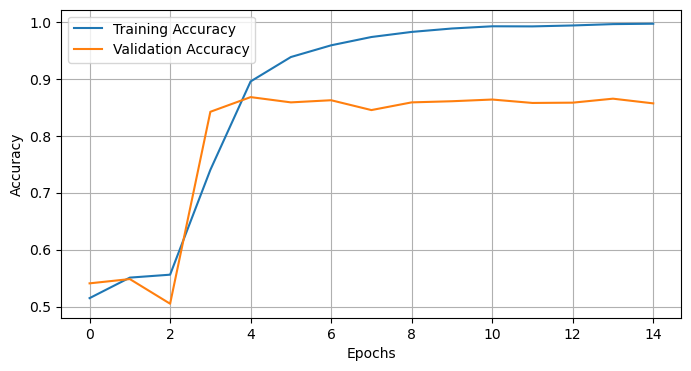

In [ ]:
def create_GRU():
    model = Sequential([
        Embedding(input_dim = MAX_FEATURES , output_dim = 128 , input_length = MAX_LEN),
        GRU(units = 64, return_sequences = False),
        Dropout(0.4),
        Dense(32 , activation = 'relu'),
        Dense(1, activation = 'sigmoid')
    ])
    return model
GRU_model = create_GRU()
GRU_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

GRU_history = GRU_model.fit(
    x_train , y_train,
    batch_size = 128,
    epochs = 15,
    validation_split = 0.2
)

final_train_acc_GRU = GRU_history.history['accuracy'][-1]
print(f'Final Trainig Accuracy :- {final_train_acc_GRU}')
final_val_acc_GRU = GRU_history.history['val_accuracy'][-1]
print(f'The Final Validation Accuracy :- {final_val_acc_GRU}')

plt.figure(figsize = (8,4))
plt.plot(GRU_history.history['accuracy'] , label = 'Training Accuracy')
plt.plot(GRU_history.history['val_accuracy'] , label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

# HYPER PARAMETER - TUNING:-

In [80]:
#models = ['rnn' , 'lstm' , 'gru']
#emb_dias = [32,64,128]
#units = [32,64,128]
#dropouts = [0.2,0.3,0.4,0.5]
#learning_rates = [0.001 , 0.01]

In [81]:
param_grid = {
    'models'        : ['RNN' , 'LSTM' , 'GRU'],
    'embedding_dim' : [32,64,128],
    'units'         : [64,128],
    'dropout_rate'     : [0.2,0.3,0.4,0.5],
    'learning_rate': [0.001 , 0.1]
}

In [82]:
from tensorflow.keras.optimizers import Adam

In [83]:
def create_model_with_params(models = 'LSTM',embedding_dim = 32,units = 64,dropout_rate = 0.4, learning_rate = 0.1):
    model = Sequential([
        Embedding(MAX_FEATURES , embedding_dim , input_length = MAX_LEN)
    ])
    if model == 'LSTM':
        model.add(LSTM(units,return_sequences = False))
    elif model == 'RNN':
        model.add(SimpleRNN(units , return_sequences = False))
    else:
        model.add(GRU(units , return_sequences = False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(32 , activation = 'relu'))
    model.add(Dense(1 , activation = 'sigmoid'))

    # Compilation Part:-

    model.compile(
        optimizer = Adam(learning_rate = learning_rate),
        loss = 'binary_crossentropy',
        metrics =['accuracy']
    )
    return model

# Random Search Hyper Parameters:- 

In [84]:
def random_search(n_trails):
    results = []
    np.random.seed(10)
    for i in range(n_trails):
        params = {
            'models' : str(np.random.choice(param_grid['models'])),
             'embedding_dim' : int(np.random.choice(param_grid['embedding_dim'])),
            'units' : int(np.random.choice(param_grid['units'])),
            'dropout_rate' : float(np.random.choice(param_grid['dropout_rate'])),
            'learning_rate' : float(np.random.choice(param_grid['learning_rate']))
        } 
            
        print(f'\n-----Trail {i+1}/{n_trails}-----\n')
        print(f'Parameters :- {params}-----\n')

        try:
            model = create_model_with_params(**params)
            history = model.fit(
                x_train , y_train,
                epochs = 10, validation_split = 0.20
            )
            validation_accuracy = max(history.history['val_accuracy'])
            validation_loss = min(history.history['val_loss'])

            results.append({
                'Train' : i+1,
                'Parameters' : params,
                'Val_Accuracy' : validation_accuracy,
                'Model' : model})
            print(f'\nValidation Accuracy :- {validation_accuracy:.2f}\n')
        except Exception as e:
            print(f'Error in Train {i+1}:{e}')
            continue
    return results
    

In [85]:
search_results = random_search(10)


-----Trail 1/10-----

Parameters :- {'models': 'LSTM', 'embedding_dim': 64, 'units': 64, 'dropout_rate': 0.5, 'learning_rate': 0.001}-----

Epoch 1/10


C:\Users\windows 10\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.5176 - loss: 0.6908 - val_accuracy: 0.5512 - val_loss: 0.6852
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.5760 - loss: 0.6603 - val_accuracy: 0.7887 - val_loss: 0.5110
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.8661 - loss: 0.3316 - val_accuracy: 0.8780 - val_loss: 0.3005
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.9859 - loss: 0.0469 - val_accuracy: 0.8735 - val_loss: 0.4486
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.9912 - loss: 0.0326 - val_accuracy: 0.8645 - val_loss: 0.5223
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.9898 - loss: 0.0311 - val_accuracy: 0.8705 - val_loss: 0.5685
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.9935 - loss: 0.0214 - val_accuracy: 0.8633 - val_loss: 0.6902

Validation Accuracy :- 0.88


-----Trail 2/10-----

Parameters :- {'models': 'LSTM', 'embedding_dim

# Taking The Best Comanination:-

In [86]:
if search_results:
    best_result = max(search_results, key = lambda x:x['Val_Accuracy'])
    for result in search_results:
        trail = result['Train']
        acc = result['Val_Accuracy']
        model_type = result['Parameters']['models']
        print(f'Train:- {trail} : {model_type}--- Accuracy:- {acc:.2f}')
    print('THE BEST CONFIGURATION..\n')
    print(f'Best Accuracy :- {best_result['Val_Accuracy']}')
    # print(f'RNN Accuracy')
        

Train:- 1 : LSTM--- Accuracy:- 0.88
Train:- 2 : LSTM--- Accuracy:- 0.88
Train:- 3 : LSTM--- Accuracy:- 0.52
Train:- 4 : RNN--- Accuracy:- 0.87
Train:- 5 : RNN--- Accuracy:- 0.88
Train:- 6 : RNN--- Accuracy:- 0.88
Train:- 7 : RNN--- Accuracy:- 0.87
Train:- 8 : LSTM--- Accuracy:- 0.52
Train:- 9 : GRU--- Accuracy:- 0.89
Train:- 10 : GRU--- Accuracy:- 0.52
THE BEST CONFIGURATION..

Best Accuracy :- 0.8914999961853027


In [87]:
print(best_result)

{'Train': 9, 'Parameters': {'models': 'GRU', 'embedding_dim': 64, 'units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.001}, 'Val_Accuracy': 0.8914999961853027, 'Model': <Sequential name=sequential_11, built=True>}


In [88]:
best_params = best_result['Parameters']
best_params

{'models': 'GRU',
 'embedding_dim': 64,
 'units': 64,
 'dropout_rate': 0.4,
 'learning_rate': 0.001}

In [89]:
best_model = create_model_with_params(**best_params)

callbacks = [
    ModelCheckpoint(
        'best_amazon_sentiment_model.keras',
        monitor = 'val_accuracy',
        save_best_only = True,
        mode = 'max'
    ),
    EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True
    ),
    
]

In [90]:
final_history = best_model.fit(
    x_train , y_train , 
    batch_size = 64,
    epochs = 30,
    validation_split = 0.20,
    callbacks = callbacks
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.5146 - loss: 0.6921 - val_accuracy: 0.5435 - val_loss: 0.6866
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.5515 - loss: 0.6751 - val_accuracy: 0.5660 - val_loss: 0.6796
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.6061 - loss: 0.6472 - val_accuracy: 0.7558 - val_loss: 0.6499
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8595 - loss: 0.3418 - val_accuracy: 0.8625 - val_loss: 0.3314
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.9220 - loss: 0.2127 - val_accuracy: 0.8723 - val_loss: 0.3340
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.9557 - loss: 0.1337 - val_accuracy: 0.8627 - val_loss: 0.3751
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.9716 - loss: 0.0908 - val_accuracy: 0.8618 - val_loss: 0.4637
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.9808 - loss: 0.0626 - 

In [91]:
best_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (64, 100, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_11 (GRU)                    │ (64, 64)               │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (64, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (64, 32)               │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (64, 1)                │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,001,221 (7.63 MB)

 Trainable params: 667,073 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,334,148 (5.09 MB)

In [97]:
test_loss, test_acc = best_model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = (best_model.predict(x_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8526 - loss: 0.3495
Test Accuracy: 0.8526
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85      2485
    Positive       0.85      0.86      0.85      2515

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



# Loading The Model And Tokenizer:-

In [98]:
loaded_model = load_model('best_amazon_sentiment_model.keras')
with open('amezon_sentiment_tokenizer.pkl','rb') as f:
    loaded_tokenizer = pickle.load(f)

# How It Works On An Real World Text:-

In [114]:
my_sent = 'I Ate This <chocolate> which is just like an tootpast taste'

def predict_statement(text):
    clean = Clean_Text(text)
    sequence = loaded_tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(sequence, maxlen = MAX_LEN,padding = 'post')
    prob = loaded_model.predict(padded)[0][0]
    sentiment = 'Positive' if prob > 0.5 else 'Negative'

    return sentiment, prob
    
    

In [115]:
predict_statement(my_sent)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


('Negative', np.float32(0.2189229))

In [116]:
sent_2 = " I happy for buying again."
predict_statement(sent_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


('Positive', np.float32(0.72158605))

In [118]:
snet_3 = 'i hate that product'
predict_statement(snet_3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


('Negative', np.float32(0.44493344))

In [121]:
s_5 = 'this is a beatifull product'
predict_statement(s_5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


('Positive', np.float32(0.76883185))